<a href="https://www.kaggle.com/code/samanvithkashyap/train-initial-architechure?scriptVersionId=299803245" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# ArtExtract — Style Classification with CRNN
Baseline model for classifying WikiArt paintings by art style using a 
Convolutional-Recurrent Neural Network (EfficientNet-B0 + BiGRU).
Dataset: WikiArt (29 styles, ~81k images)

In [28]:
# Imports
import os
import pandas as pd
import random
import torch
import torch.nn as nn
from PIL import Image, ImageFile
import torch.optim as optim
from torch.utils.data import DataLoader,Dataset
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from tqdm import tqdm
import torch.nn.functional as F

## 1. Dataset Loader
Custom PyTorch Dataset class for WikiArt. Handles corrupted images gracefully 
by retrying with a random sample instead of crashing the training loop.

In [31]:
class WikiArt(Dataset):
    def __init__(self, csv_file, img_dir, transform=None):
        self.annotations = pd.read_csv(csv_file, header=None)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.annotations)

    def __getitem__(self, index):
        try:
            img_name = self.annotations.iloc[index, 0] 
            img_path = os.path.join(self.img_dir, str(img_name))
            
            image = Image.open(img_path).convert("RGB")
            label = int(self.annotations.iloc[index, 1]) 

            if self.transform:
                image = self.transform(image)
            return image, label, img_path
            
        except Exception as e:
            return self.__getitem__((index + 1) % len(self.annotations))


## 2. Model Architecture — ArtCRNN
EfficientNet-B0 as CNN backbone for feature extraction, followed by a 
Bidirectional GRU that scans feature columns left-to-right and right-to-left.
Justified for style classification because brushstroke patterns are sequential 
spatial features that repeat across the canvas.

In [18]:
# CRNN architechure
class ArtCRNN(nn.Module):
    def __init__(self, num_classes):
        super(ArtCRNN, self).__init__()
        basemodel = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
        self.cnn = basemodel.features
        
        self.rnn_input_dim = 1280 * 8 
        self.hidden_size = 256
        
        self.rnn = nn.GRU(
            input_size=self.rnn_input_dim, 
            hidden_size=self.hidden_size, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        self.fc = nn.Linear(self.hidden_size * 2, num_classes)
        
    def forward(self, x):
        conv_out = self.cnn(x) 
        batch_size, channels, height, width = conv_out.size()
        
        rnn_in = conv_out.permute(0, 3, 1, 2).contiguous()
        rnn_in = rnn_in.view(batch_size, width, channels * height)
        
        rnn_out, hidden = self.rnn(rnn_in)
        last_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        output = self.fc(last_hidden)
        return output

## 3. Training
AdamW optimizer with CosineAnnealingLR scheduler and mixed precision (fp16) 
for faster GPU training. Loss dropped from 1.69 → 0.64 over 5 epochs.

In [19]:
def train_model(model, train_loader, device, epochs=5):
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()
    scaler = torch.amp.GradScaler('cuda')
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    model.train()
    
    for epoch in range(epochs):
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        
        for images, labels, _ in progress_bar:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        scheduler.step()
        print(f"Epoch {epoch+1} Average Loss: {running_loss/len(train_loader):.4f}")

## 4. Outlier Detection
Identifies paintings that don't fit their assigned style using per-image 
cross-entropy loss. High loss + high confidence = genuine outlier, not just 
a hard example. These may represent mislabeled paintings or artists working 
outside their typical style.

In [20]:
def find_outliers(model, val_loader, device):
    model.eval()
    outlier_criterion = nn.CrossEntropyLoss(reduction='none')
    outlier_data = []
    seen_paths = set()
    
    with torch.no_grad():
        for images, labels, image_paths in tqdm(val_loader, desc="Hunting Outliers"):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            losses = outlier_criterion(outputs, labels)
            
            probabilities = F.softmax(outputs, dim=1)
            predicted_classes = torch.argmax(probabilities, dim=1)
            
            for i in range(len(images)):
                path = image_paths[i]
                if path not in seen_paths:
                    seen_paths.add(path)
                    confidence = probabilities[i][predicted_classes[i]].item()
                    outlier_data.append({
                        'image_path': path,
                        'true_label': labels[i].item(),
                        'predicted_label': predicted_classes[i].item(),
                        'loss': losses[i].item(),
                        'confidence': confidence
                    })
    
    df_outliers = pd.DataFrame(outlier_data)
    top_outliers = df_outliers.sort_values(by='loss', ascending=False).head(10)
    return top_outliers

In [21]:
# paths
TRAIN_CSV = "/kaggle/input/datasets/samanvithkashyap/art-csv/style_train.csv" 
VAL_CSV = "/kaggle/input/datasets/samanvithkashyap/art-csv/style_val.csv"
IMG_DIR = "/kaggle/working/wikiart_resized" 

# hyperparameters
batch_size = 64
num_workers = 4
num_epochs = 5
num_classes = 29
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

image_transforms = transforms.Compose([
transforms.Resize((256, 256)),
transforms.ToTensor(),
transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = WikiArt(csv_file=TRAIN_CSV, img_dir=IMG_DIR, transform=image_transforms)
val_dataset = WikiArt(csv_file=VAL_CSV, img_dir=IMG_DIR, transform=image_transforms)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers,pin_memory=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers,pin_memory=True)

model = ArtCRNN(num_classes=num_classes).to(device)
print("Starting Training")
train_model(model, train_loader, device, epochs=num_epochs)
torch.save(model.state_dict(), "artcrnn_weights.pth")
top_10 = find_outliers(model, val_loader, device)
top_10.to_csv("top_10_outliers.csv", index=False)


Starting Training


Epoch 1/5: 100%|██████████| 892/892 [03:11<00:00,  4.66it/s, loss=1.31]


Epoch 1 Average Loss: 1.6856


Epoch 2/5: 100%|██████████| 892/892 [03:11<00:00,  4.67it/s, loss=1.9]  


Epoch 2 Average Loss: 1.3764


...

Epoch 4/5: 100%|██████████| 892/892 [03:11<00:00,  4.67it/s, loss=2.37] 


Epoch 4 Average Loss: 0.8694


Epoch 5/5: 100%|██████████| 892/892 [03:11<00:00,  4.67it/s, loss=6.45] 


Epoch 5 Average Loss: 0.6095


Hunting Outliers: 100%|██████████| 382/382 [00:42<00:00,  8.95it/s]


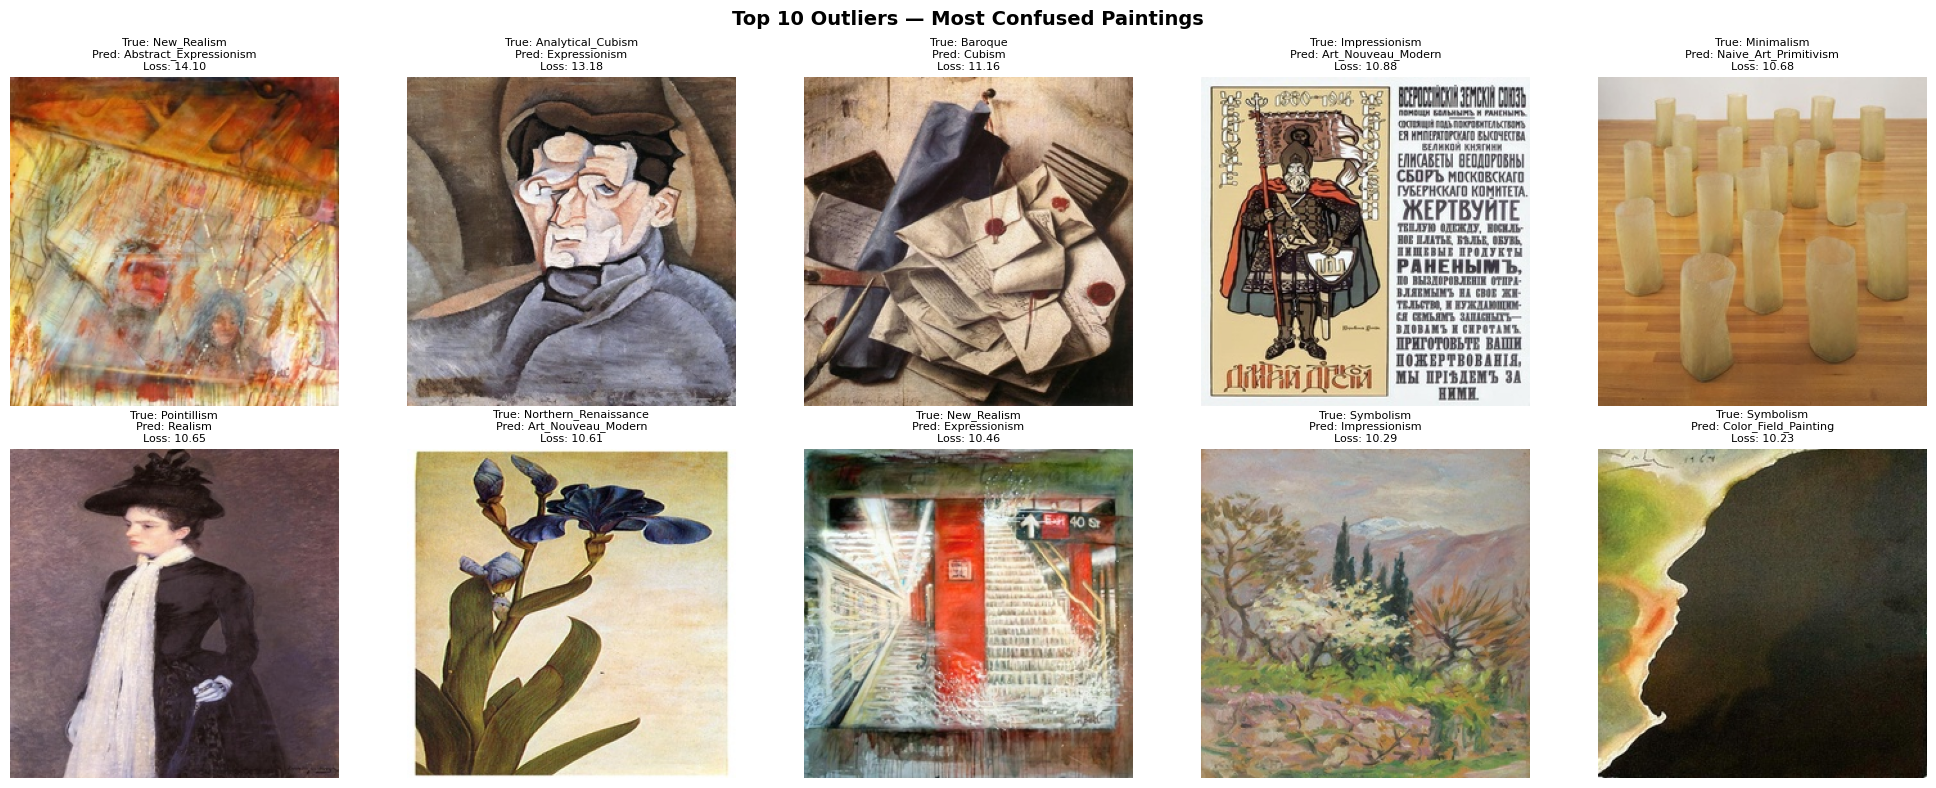

In [22]:
import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

style_names = sorted([d for d in os.listdir('/kaggle/input/wikiart') 
                      if os.path.isdir(os.path.join('/kaggle/input/wikiart', d))])

for idx, (_, row) in enumerate(top_10.iterrows()):
    img_path = os.path.join('/kaggle/working', row['image_path'])
    img = Image.open(img_path)
    axes[idx].imshow(img)
    axes[idx].set_title(
        f"True: {style_names[row['true_label']]}\n"
        f"Pred: {style_names[row['predicted_label']]}\n"
        f"Loss: {row['loss']:.2f}",
        fontsize=8
    )
    axes[idx].axis('off')

plt.suptitle('Top 10 Outliers — Most Confused Paintings', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outliers_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Results & Findings
Top outliers reveal interesting edge cases:
- Jackson Pollock (Abstract Expressionism) confused with Baroque — his drip 
  paintings are visually unlike anything else in the dataset
- Hilma af Klint (Symbolism) confused with Minimalism — she was painting 
  abstract geometric works decades before the movement existed
- Baroque trompe l'oeil still life confused with Synthetic Cubism — flat 
  overlapping composition creates visual similarity